In [1]:
import torch

from torchvision import transforms
from torchvision.utils import save_image
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions
from social_media_overlay.ext.imaginaire.config import Config
from social_media_overlay.ext.imaginaire.generators.munit import Generator
from social_media_overlay.ext.imaginaire.discriminators.munit import Discriminator

In [2]:
def get_relevant_states(state_dict, use_averaged_model=False):
    # Conditional logic to keep or delete keys
    if use_averaged_model:
        # Keep only keys that contain 'averaged_model'
        filtered_dict = {k.replace("module.", ""): v for k, v in state_dict.items() if 'averaged_model' in k}
    else:
        # Delete keys that contain 'averaged_model'
        filtered_dict = {k.replace("module.", ""): v for k, v in state_dict.items() if 'averaged_model' not in k}

    if "num_updates_tracked" in filtered_dict:
        del filtered_dict["num_updates_tracked"]
    return filtered_dict

# helper: your pipeline normalizes to [-1, 1], so this converts back to [0, 1] for saving/viewing
def denorm(x):
    return (x.clamp(-1, 1) + 1) / 2


In [3]:
input_size = 1024
crop_size = 1024
batch_size = 1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_transforms = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
dataset_test = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=0)

cfg = Config("../src/social_media_overlay/ext/imaginaire/imagenet2imagenet.yaml")
gen = Generator(cfg.gen, cfg.data)

state_dict = torch.load("../data/gebhardt/models/imaginaire_munit_200000_s5.pt")

gen_sate_dict = get_relevant_states(state_dict['net_G'])
gen.load_state_dict(gen_sate_dict)
gen = gen.to(device)


dis = Discriminator(cfg.dis, cfg.data)
dis_sate_dict = get_relevant_states(state_dict['net_D'])
dis.load_state_dict(dis_sate_dict)
dis = dis.to(device)

COCO Dataset Debug Info
Root: ../data/coco
Split: val
Annotation file: ../data/coco/annotations/captions_val2017.json
Image directory: ../data/coco/val2017
Root exists ✓
Annotation file exists ✓
Image directory exists ✓
Images found in directory: 5000
Loading annotation metadata...
Entries in image_list: 5000
Dataset initialization finished.
Done with the Multi-resolution patch discriminator initialization.
Done with the Multi-resolution patch discriminator initialization.


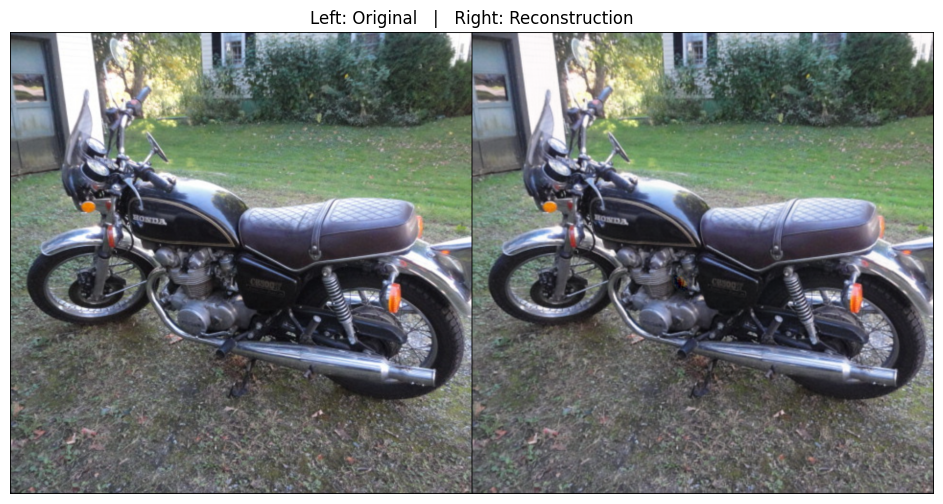

In [4]:
with torch.no_grad():
    batch = next(iter(data_loader))
    x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch["images"].to(device)
    x = x.to(device)

    # encode
    content_a, style_a = gen.autoencoder_a.encode(x)

    # reconstruct
    x_recon = gen.autoencoder_a.decode(content_a, style_a)

    # take first image in batch
    original = denorm(x[0]).detach().cpu()
    reconstructed = denorm(x_recon[0]).detach().cpu()

    # stack side-by-side
    comparison = make_grid([original, reconstructed], nrow=2)

    plt.figure(figsize=(12,6))
    plt.imshow(comparison.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Left: Original   |   Right: Reconstruction")
    plt.show()

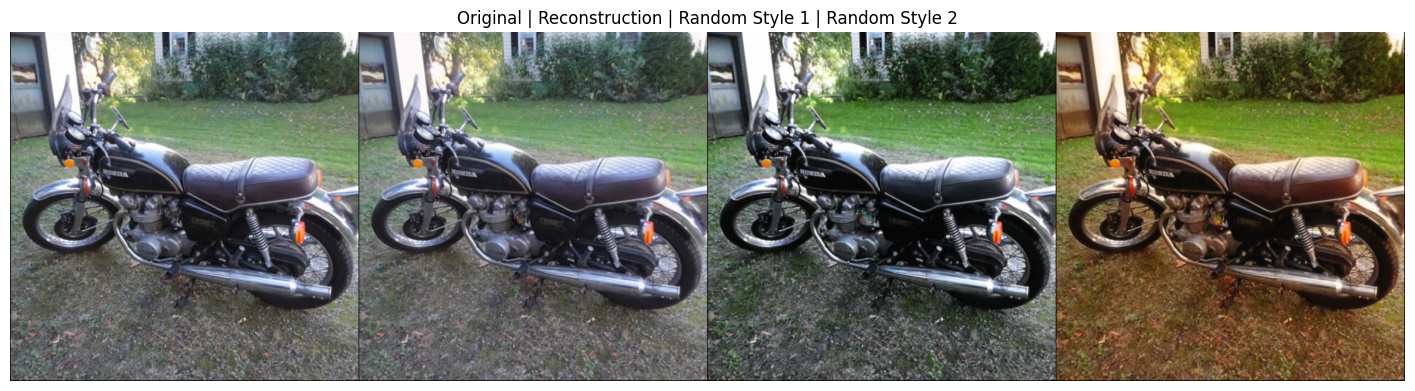

In [5]:
with torch.no_grad():
    x = x.to(device)

    # Encode content from your image
    content, style = gen.autoencoder_a.encode(x)

    # Normal reconstruction (same style)
    x_recon = gen.autoencoder_a.decode(content, style)

    # Get style dimension
    style_dim = style.shape[1]

    # Sample two random styles
    style_rand1 = torch.randn(x.size(0), style_dim, 1, 1, device=x.device)
    style_rand2 = torch.randn(x.size(0), style_dim, 1, 1, device=x.device)

    # Decode with random styles
    x_rand1 = gen.autoencoder_a.decode(content, style_rand1)
    x_rand2 = gen.autoencoder_a.decode(content, style_rand2)

    # Prepare images for display
    original = denorm(x[0]).cpu()
    recon = denorm(x_recon[0]).cpu()
    rand1 = denorm(x_rand1[0]).cpu()
    rand2 = denorm(x_rand2[0]).cpu()

    # Stack horizontally
    comparison = make_grid([original, recon, rand1, rand2], nrow=4)

    plt.figure(figsize=(18,6))
    plt.imshow(comparison.permute(1,2,0))
    plt.axis("off")
    plt.title("Original | Reconstruction | Random Style 1 | Random Style 2")
    plt.show()